# **Load The Modules**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

# **Load the data**


In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d douhanyarenolu/tess-dataset

Dataset URL: https://www.kaggle.com/datasets/douhanyarenolu/tess-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
 99% 211M/214M [00:00<00:00, 510MB/s] 
100% 214M/214M [00:00<00:00, 557MB/s]


In [ ]:
!unzip tess-dataset.zip

Archive:  tess-dataset.zip
  inflating: TESS/OAF_angry/OAF_back_angry.wav  
  inflating: TESS/OAF_angry/OAF_bar_angry.wav  
  inflating: TESS/OAF_angry/OAF_base_angry.wav  
  inflating: TESS/OAF_angry/OAF_bath_angry.wav  
  inflating: TESS/OAF_angry/OAF_bean_angry.wav  
  inflating: TESS/OAF_angry/OAF_beg_angry.wav  
  inflating: TESS/OAF_angry/OAF_bite_angry.wav  
  inflating: TESS/OAF_angry/OAF_boat_angry.wav  
  inflating: TESS/OAF_angry/OAF_bone_angry.wav  
  inflating: TESS/OAF_angry/OAF_book_angry.wav  
  inflating: TESS/OAF_angry/OAF_bought_angry.wav  
  inflating: TESS/OAF_angry/OAF_burn_angry.wav  
  inflating: TESS/OAF_angry/OAF_cab_angry.wav  
  inflating: TESS/OAF_angry/OAF_calm_angry.wav  
  inflating: TESS/OAF_angry/OAF_came_angry.wav  
  inflating: TESS/OAF_angry/OAF_cause_angry.wav  
  inflating: TESS/OAF_angry/OAF_chain_angry.wav  
  inflating: TESS/OAF_angry/OAF_chair_angry.wav  
  inflating: TESS/OAF_angry/OAF_chalk_angry.wav  
  inflating: TESS/OAF_angry/OAF_chat_an

In [ ]:
data_dir = '/content/TESS'

paths=[]
labels=[]

for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.wav'):
            paths.append(os.path.join(dirname, filename))
            label = filename.split('_')[-1].split('.')[0]  # Extract label from filename
            labels.append(label.lower())
    if len(paths) == 2800:
        break
print('data is loaded')

data is loaded


In [ ]:
len(paths)

2800

In [ ]:
paths[:5]

['/content/TESS/OAF_happy/OAF_have_happy.wav',
 '/content/TESS/OAF_happy/OAF_red_happy.wav',
 '/content/TESS/OAF_happy/OAF_cool_happy.wav',
 '/content/TESS/OAF_happy/OAF_time_happy.wav',
 '/content/TESS/OAF_happy/OAF_fat_happy.wav']

In [ ]:
labels[:5]

['happy', 'happy', 'happy', 'happy', 'happy']

In [ ]:
df= pd.DataFrame({'speech': paths , 'label' : labels})
df.head()

,speech,label
0,/content/TESS/OAF_happy/OAF_have_happy.wav,happy
1,/content/TESS/OAF_happy/OAF_red_happy.wav,happy
2,/content/TESS/OAF_happy/OAF_cool_happy.wav,happy
3,/content/TESS/OAF_happy/OAF_time_happy.wav,happy
4,/content/TESS/OAF_happy/OAF_fat_happy.wav,happy


In [ ]:
df['label'].value_counts()

,count
label,
happy,400
ps,400
sad,400
angry,400
fear,400
neutral,400
disgust,400


# **Exploratory Data Analysis**



<Axes: xlabel='label', ylabel='count'>

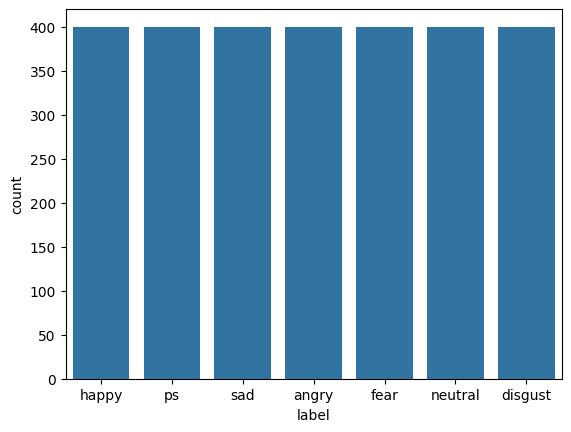

In [ ]:
sns.countplot(data=df, x='label')


In [ ]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

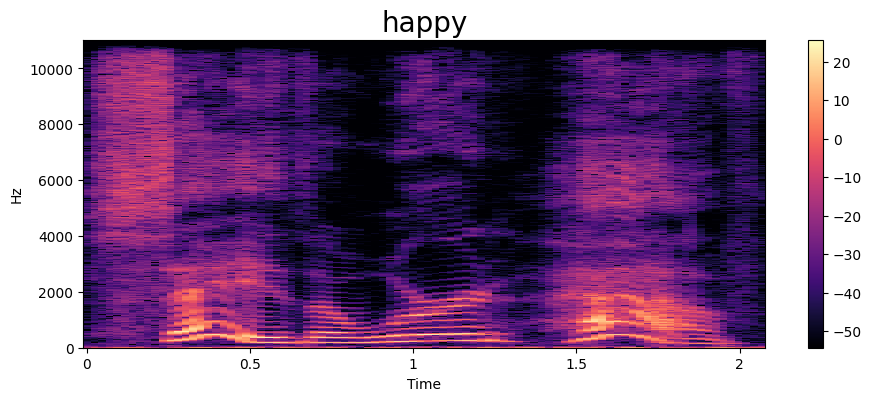

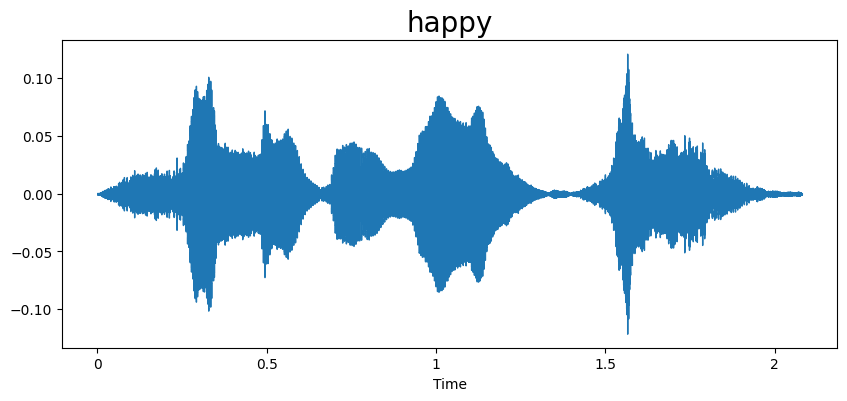

In [ ]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

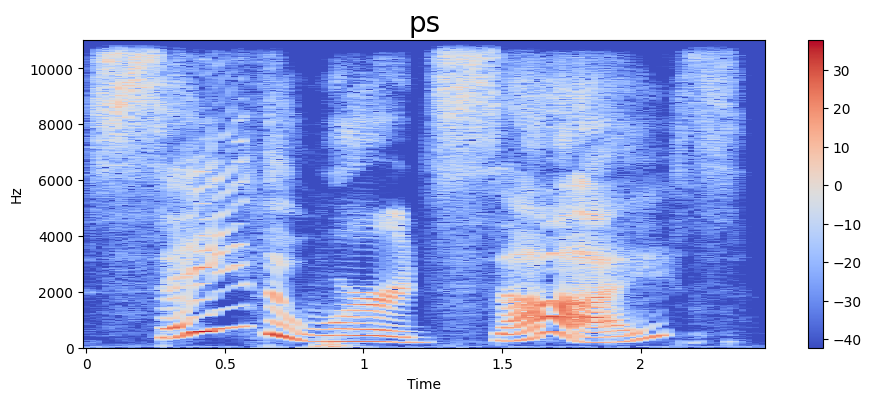

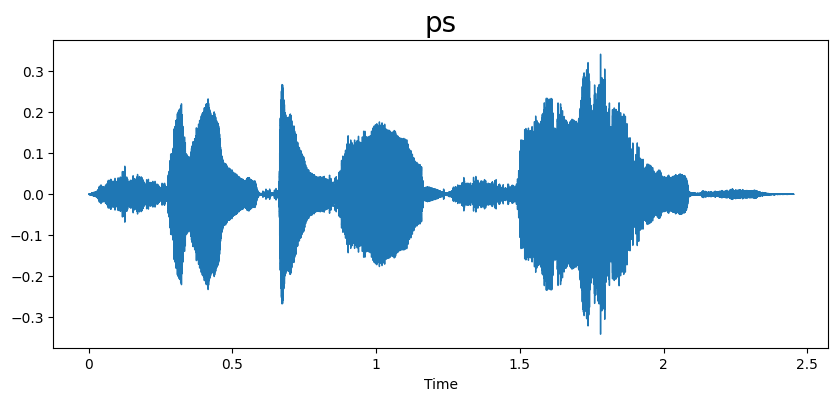

In [63]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

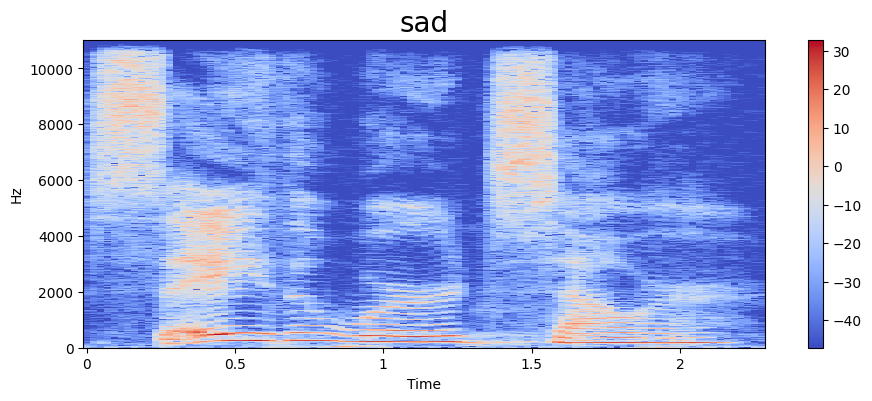

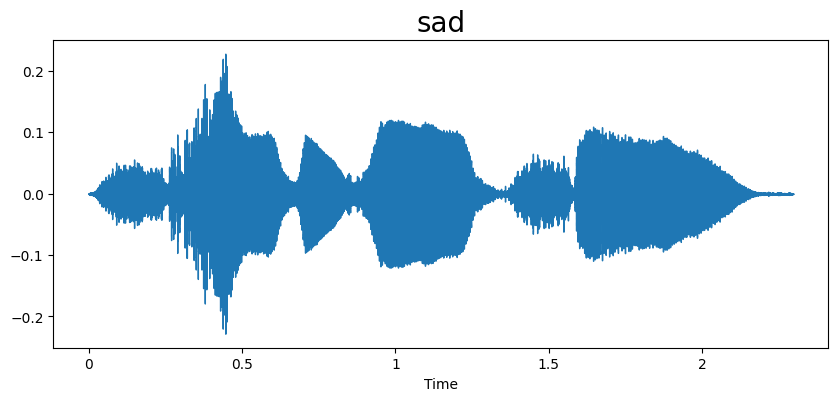

In [64]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

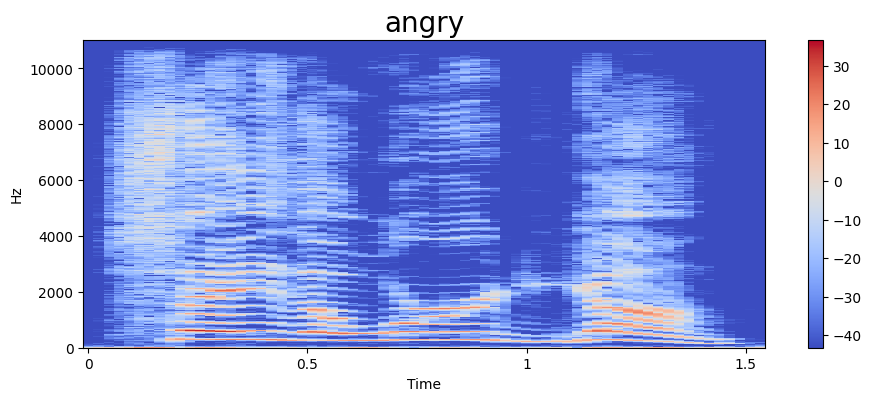

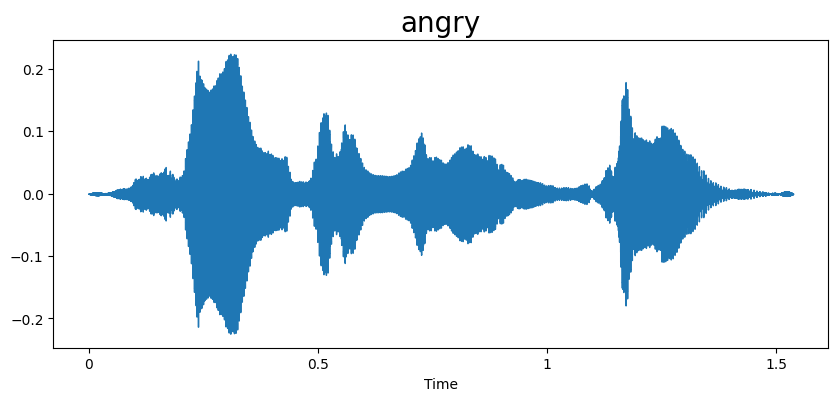

In [65]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

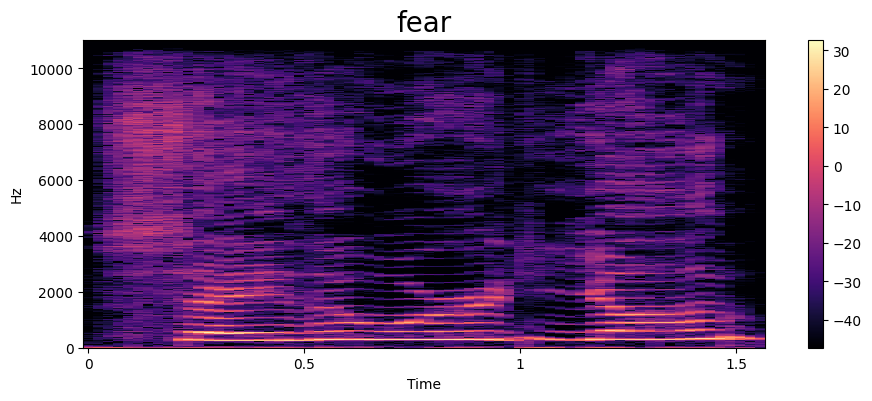

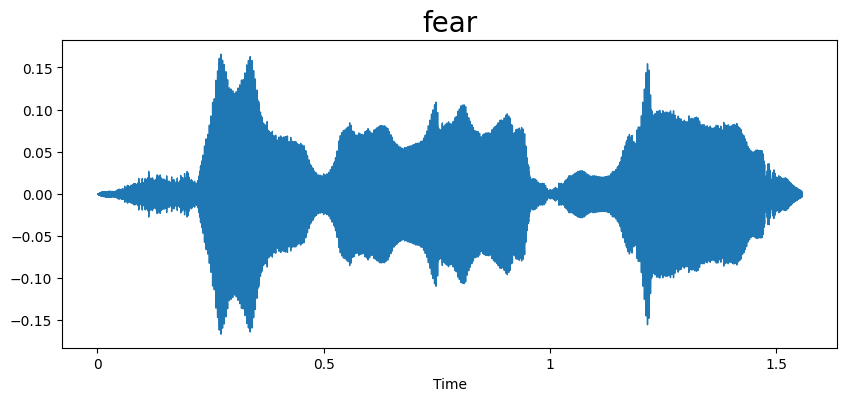

In [66]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

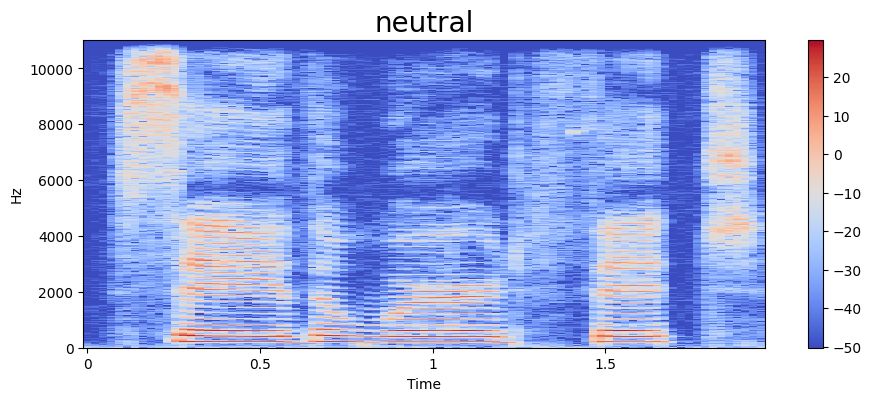

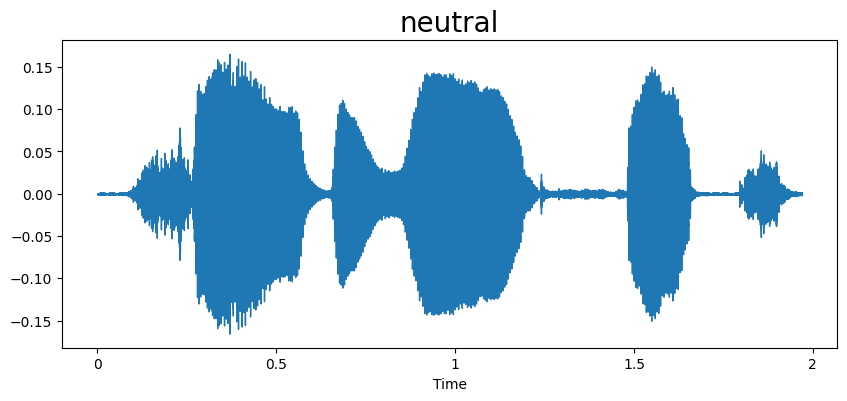

In [67]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

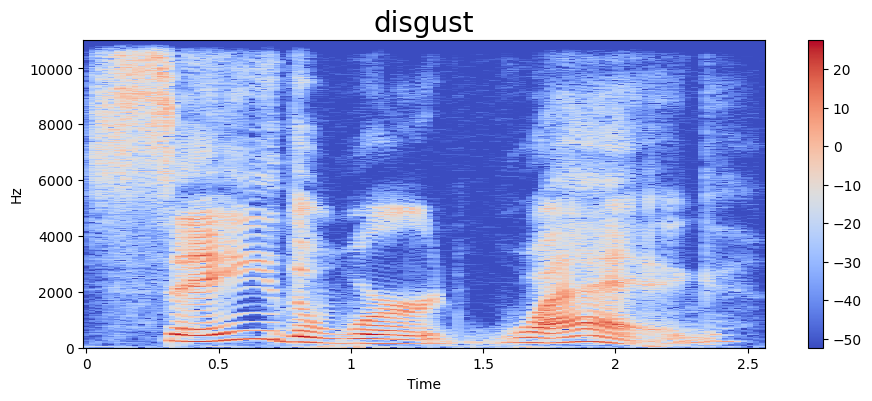

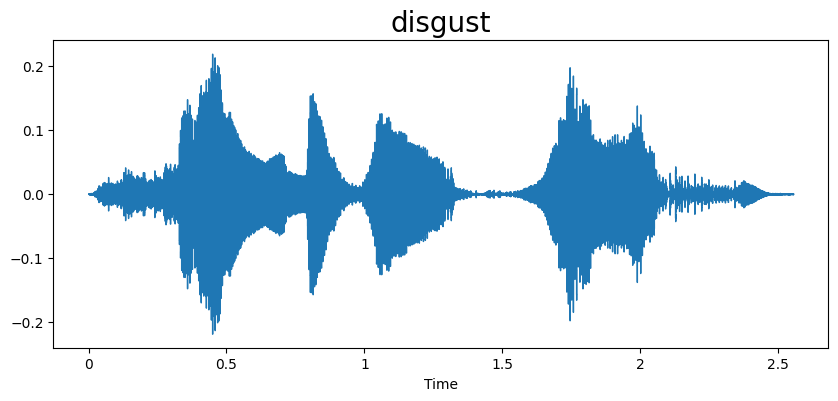

In [68]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
spectogram(data, sampling_rate, emotion)
waveplot(data, sampling_rate, emotion)
Audio(path)

# **Feature Extraction**

In [69]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [70]:
extract_mfcc(df['speech'][0])


array([-458.3612    ,  104.12472   ,    2.9531555 ,  -18.744722  ,
          2.813324  ,    6.507822  ,   -8.923658  ,    2.7663522 ,
         -7.4409657 ,   -7.1654496 ,   -6.6010313 ,  -10.979858  ,
         -4.961738  ,   -2.1480408 ,    2.490297  ,   -0.89367664,
         -3.281015  ,   11.305066  ,   -0.7850674 ,   -5.2087297 ,
          0.49085903,    2.6904314 ,   -5.1819906 ,    3.1850686 ,
         -8.551519  ,    4.239318  ,    1.5135657 ,    8.497774  ,
          7.67529   ,   11.114362  ,    3.4013546 ,    5.427509  ,
          1.7291932 ,    2.1614432 ,    4.733095  ,    8.608318  ,
          6.8215117 ,    9.370498  ,    8.942533  ,   10.898576  ],
      dtype=float32)

In [71]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))


In [72]:
X_mfcc

,speech
0,"[-458.3612, 104.12472, 2.9531555, -18.744722, ..."
1,"[-471.84747, 122.48374, 23.215225, -19.038057,..."
2,"[-482.05246, 107.49035, 33.264, -9.05529, -9.5..."
3,"[-472.727, 108.8073, 10.037444, -10.20021, 6.4..."
4,"[-424.2528, 89.54188, 3.097347, -20.75539, 3.4..."
...,...
2795,"[-517.1681, 60.967583, 18.917559, 17.190458, 1..."
2796,"[-532.7092, 115.8892, 31.842361, -8.6610155, 1..."
2797,"[-528.0314, 97.87455, 21.352137, 5.0554585, 12..."
2798,"[-519.48254, 87.98961, 20.64989, 3.5186672, 17..."


In [73]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [74]:
X = np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [81]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])
y = y.toarray()

In [82]:
y.shape

(2800, 7)

# **Create the LSTM Model**




In [118]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40,1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# Train the model
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=64)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4447 - loss: 1.4831 - val_accuracy: 0.3571 - val_loss: 2.2076
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8336 - loss: 0.4462 - val_accuracy: 0.3518 - val_loss: 2.2560
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9254 - loss: 0.2362 - val_accuracy: 0.5268 - val_loss: 1.4030
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9511 - loss: 0.1541 - val_accuracy: 0.6589 - val_loss: 1.4921
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9562 - loss: 0.1459 - val_accuracy: 0.6482 - val_loss: 1.7498
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9782 - loss: 0.0728 - val_accuracy: 0.7500 - val_loss: 1.2595
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9717 - loss: 0.0935 - val_accuracy: 0.5393 - val_loss: 2.8643
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9841 - loss: 0.0631 - val_accuracy: 0.6411 - val_lo

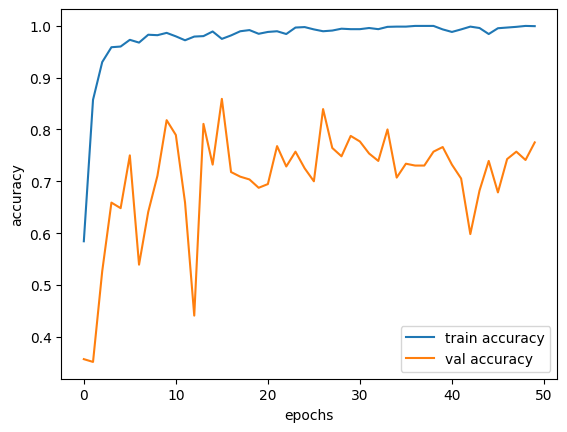

In [120]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

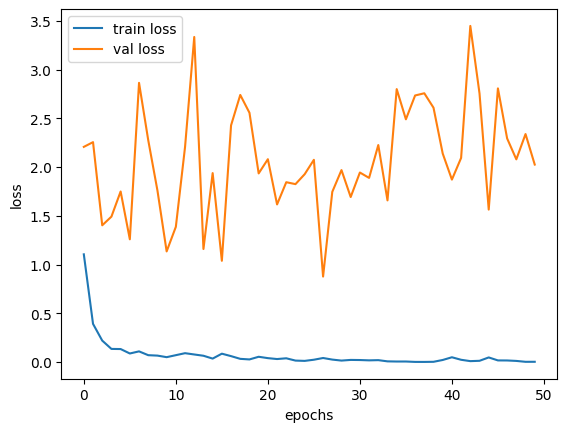

In [121]:
epochs = list(range(50))
acc = history.history['loss']
val_acc = history.history['val_loss']

plt.plot(epochs, acc, label='train loss')
plt.plot(epochs, val_acc, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

####AS we see The model is facing an overfitting problem. I will address it by simplifying the model, increasing dropout, using regularization, and applying data augmentation and cross-validation.

In [122]:
def augment_audio(y, sr):

    noise = 0.005 * np.random.randn(len(y))
    y_noisy = y + noise
    y_speed = librosa.effects.time_stretch(y, rate=1.1)
    y_pitch = librosa.effects.pitch_shift(y, sr, n_steps=2)
    return [y, y_noisy, y_speed, y_pitch]  # Multiple versions of the same file

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(40, 1), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
history = model.fit(
    X, y,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

from sklearn.model_selection import KFold
folds = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in folds.split(X):
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(40, 1), kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(7, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X[train_idx], y[train_idx], validation_data=(X[val_idx], y[val_idx]), epochs=30)


Epoch 1/80
68/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2701 - loss: 2.4159

70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2747 - loss: 2.3965 - val_accuracy: 0.2839 - val_loss: 2.0964
Epoch 2/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5368 - loss: 1.3273 - val_accuracy: 0.3464 - val_loss: 2.1482
Epoch 3/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6651 - loss: 0.9628 - val_accuracy: 0.3571 - val_loss: 2.1703
Epoch 4/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7850 - loss: 0.7257 - val_accuracy: 0.3571 - val_loss: 2.1357
Epoch 5/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8616 - loss: 0.4994 - val_accuracy: 0.3571 - val_loss: 2.2173
Epoch 6/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8986 - loss: 0.4048 - val_accuracy: 0.3571 - val_loss: 2.7113
Epoch 7/80
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9050 - loss: 0.4238 - val_accuracy: 0.3536 - val_loss: 2.1612
Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2458 - loss: 2.4234 - val_accuracy: 0.4321 - val_loss: 1.559

In [108]:
model.load_weights('best_model.h5')


In [114]:
from keras.models import load_model

model = load_model('best_model.h5')
loss, accuracy = model.evaluate(X[val_idx], y[val_idx])
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9611 - loss: 0.1826
Validation Loss: 0.2585
Validation Accuracy: 0.9536


In [115]:
from keras.models import load_model

model = load_model('best_model.h5')

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(X[val_idx], y[val_idx])
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Evaluate on training set
train_loss, train_accuracy = model.evaluate(X[train_idx], y[train_idx])
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9611 - loss: 0.1826
Validation Loss: 0.2585
Validation Accuracy: 0.9536
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9378 - loss: 0.2308
Train Loss: 0.2909
Train Accuracy: 0.9344


# **The problem is Solved**
